## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import (
    find_peaks,
    savgol_filter
)
import h5py

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [22]:
from models.PINN import get_systolic_peak,calculate_derivatives, get_dicrotic_notch, extract_delay_times, get_delay_time, prepare_UCI_dataset, estimate_RC

ImportError: cannot import name 'estimate_RC' from 'models.PINN' (/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/../models/PINN.py)

In [9]:
FS = 125
WINDOW_SIZE = 1000

MAT_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/data/Part_1.mat"
f = h5py.File(MAT_PATH, "r")

dataset = f["Part_1"]

# print("Number of recordings:", dataset.shape[0])
ref = dataset[1,0 ]

recording = f[ref][:]

print("Recording shape:", recording.shape)
ppg = recording[:, 0]
abp = recording[:, 1]

print("PPG length:", len(ppg))
print("ABP length:", len(abp))
ppg_std = np.std(ppg)


ppg = (ppg - np.mean(ppg)) / ppg_std # Normalize PPG signal
START = 0

ppg_window = ppg[
    START:START + WINDOW_SIZE
]

print("Window shape:", ppg_window.shape)


# ==========================================
# Detect ALL systolic peaks
# ==========================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print(
    "Number of systolic peaks:",
    len(sys_peaks)
)

print(
    "Systolic peak indices:",
    sys_peaks
)


# ==========================================
# Find notch after EACH systolic peak
# ==========================================

notches = []

for sys_idx in sys_peaks:

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        FS
    )

    notches.append(notch_idx)


# ==========================================
# Print results
# ==========================================

print("\nDetected landmarks:")

for i, (sys_idx, notch_idx) in enumerate(
    zip(sys_peaks, notches)
):

    print(
        f"Beat {i+1}: "
        f"Systolic = {sys_idx} "
        f"({sys_idx / FS:.3f} s), "
        f"Notch = {notch_idx}"
    )


delay_times = []

for sys_idx, notch_idx in zip(
    sys_peaks,
    notches
):

    if notch_idx is None:
        delay_times.append(np.nan)

    else:

        delay = (
            notch_idx - sys_idx
        ) / FS

        delay_times.append(delay)


delay_times = np.array(
    delay_times,
    dtype=np.float32
)


print("\nPeak → notch delays:")

for i, delay in enumerate(delay_times):

    if np.isnan(delay):

        print(
            f"Beat {i+1}: Detection failed"
        )

    else:

        print(
            f"Beat {i+1}: "
            f"{delay:.3f} seconds"
        )


Recording shape: (61000, 3)
PPG length: 61000
ABP length: 61000
Window shape: (1000,)
Number of systolic peaks: 15
Systolic peak indices: [ 54 119 184 249 312 377 442 506 569 633 697 761 824 886 950]

Detected landmarks:
Beat 1: Systolic = 54 (0.432 s), Notch = 74
Beat 2: Systolic = 119 (0.952 s), Notch = 138
Beat 3: Systolic = 184 (1.472 s), Notch = 203
Beat 4: Systolic = 249 (1.992 s), Notch = 267
Beat 5: Systolic = 312 (2.496 s), Notch = 333
Beat 6: Systolic = 377 (3.016 s), Notch = 397
Beat 7: Systolic = 442 (3.536 s), Notch = 461
Beat 8: Systolic = 506 (4.048 s), Notch = 526
Beat 9: Systolic = 569 (4.552 s), Notch = 588
Beat 10: Systolic = 633 (5.064 s), Notch = 652
Beat 11: Systolic = 697 (5.576 s), Notch = 716
Beat 12: Systolic = 761 (6.088 s), Notch = 783
Beat 13: Systolic = 824 (6.592 s), Notch = 844
Beat 14: Systolic = 886 (7.088 s), Notch = 907
Beat 15: Systolic = 950 (7.600 s), Notch = 970

Peak → notch delays:
Beat 1: 0.160 seconds
Beat 2: 0.152 seconds
Beat 3: 0.152 secon

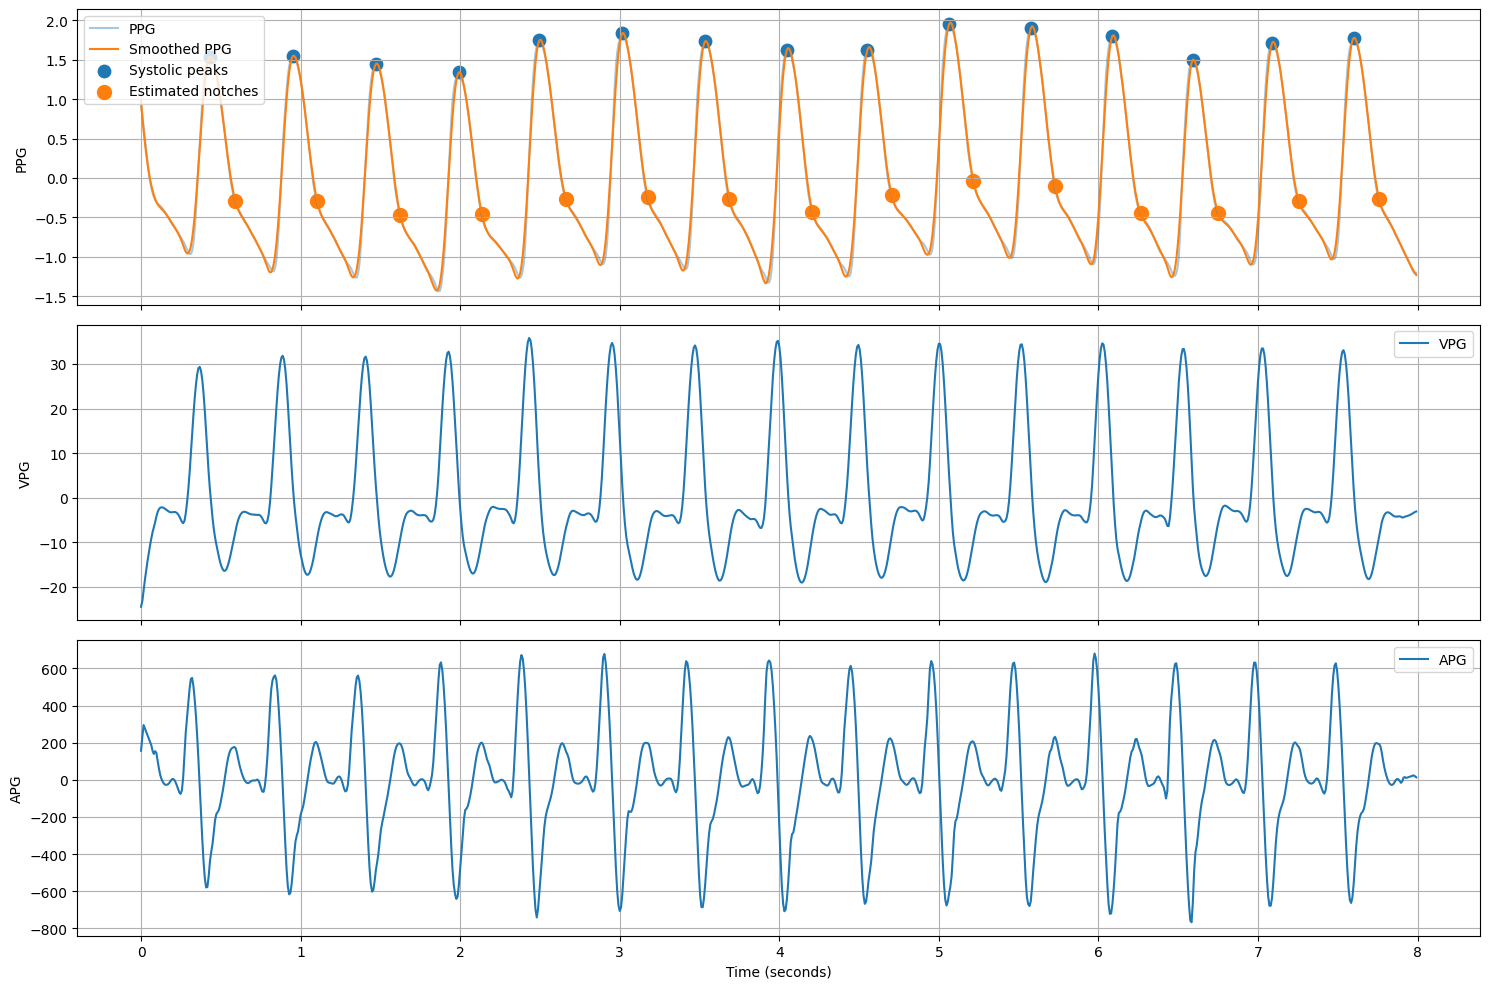

In [10]:
smooth_ppg = savgol_filter(
    ppg_window,
    window_length=21,
    polyorder=3
)
vpg = np.gradient(smooth_ppg) * FS
apg = np.gradient(vpg) * FS


time = np.arange(
    len(ppg_window)
) / FS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)


# ==================================================
# PPG
# ==================================================

axes[0].plot(
    time,
    ppg_window,
    alpha=0.4,
    label="PPG"
)

axes[0].plot(
    time,
    smooth_ppg,
    label="Smoothed PPG"
)


# All systolic peaks

axes[0].scatter(
    sys_peaks / FS,
    smooth_ppg[sys_peaks],
    s=80,
    label="Systolic peaks"
)


# All detected notches

valid_notches = [
    n for n in notches
    if n is not None
]

if len(valid_notches) > 0:

    valid_notches = np.array(
        valid_notches,
        dtype=int
    )

    axes[0].scatter(
        valid_notches / FS,
        smooth_ppg[valid_notches],
        s=100,
        label="Estimated notches"
    )


axes[0].set_ylabel("PPG")
axes[0].legend()
axes[0].grid()


# ==================================================
# VPG
# ==================================================

axes[1].plot(
    time,
    vpg,
    label="VPG"
)

axes[1].set_ylabel("VPG")
axes[1].legend()
axes[1].grid()


# ==================================================
# APG
# ==================================================

axes[2].plot(
    time,
    apg,
    label="APG"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("APG")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()

In [11]:
delay_time =  get_delay_time(ppg_window)
print(delay_time)

[0.16  0.152 0.152 0.144 0.168 0.16  0.152 0.16  0.152 0.152 0.152 0.176
 0.16  0.168 0.16 ]


In [12]:
DATA_PATH = (
    "/data1/yashvi_bhuva/"
    "BP_estimation_using_PPG/UCI/data")
X_train, y_train, delay_train, X_val, y_val, delay_val, X_test, y_test, delay_test = prepare_UCI_dataset(
    data_path=DATA_PATH)

Total recordings: 12000
Train recordings: 8400
Validation recordings: 1200
Test recordings: 2400

Processing TRAIN recordings...


Processing recordings: 100%|██████████| 8400/8400 [37:55<00:00,  3.69it/s]  


Skipped recordings: 4

Processing VALIDATION recordings...


Processing recordings: 100%|██████████| 1200/1200 [05:30<00:00,  3.63it/s]


Skipped recordings: 0

Processing TEST recordings...


Processing recordings: 100%|██████████| 2400/2400 [11:15<00:00,  3.55it/s]


Skipped recordings: 1

DATASET SHAPES
X_train: torch.Size([454999, 1, 1000])
y_train: torch.Size([454999, 2])
delay_train: torch.Size([454999])
X_val: torch.Size([65488, 1, 1000])
y_val: torch.Size([65488, 2])
delay_val: torch.Size([65488])
X_test: torch.Size([133602, 1, 1000])
y_test: torch.Size([133602, 2])
delay_test: torch.Size([133602])


In [15]:
print("Shape:", delay_train.shape)
print("Dtype:", delay_train.dtype)
print("NaN count:", np.isnan(delay_train).sum())
delay_train_np = delay_train.detach().cpu().numpy().astype(np.float32)
print(
    "NaN percentage:",
    100 * np.isnan(delay_train_np).mean(),
    "%"
)

valid_delay = delay_train_np[
    np.isfinite(delay_train_np)
]

print("Valid values:", len(valid_delay))

if len(valid_delay) > 0:

    print("\nStatistics:")

    print(
        "Min    :",
        np.min(valid_delay)
    )

    print(
        "Max    :",
        np.max(valid_delay)
    )

    print(
        "Mean   :",
        np.mean(valid_delay)
    )

    print(
        "Median :",
        np.median(valid_delay)
    )

    print(
        "Std    :",
        np.std(valid_delay)
    )

if len(valid_delay) > 0:

    print("\nRange checks:")

    print(
        "Below 0.08 s:",
        np.sum(valid_delay < 0.08)
    )

    print(
        "Above 0.35 s:",
        np.sum(valid_delay > 0.35)
    )

    print(
        "Within 0.08–0.35 s:",
        np.sum(
            (valid_delay >= 0.08) &
            (valid_delay <= 0.35)
        )
    )


if len(valid_delay) > 0:

    print("\nPercentiles:")

    for p in [1, 5, 25, 50, 75, 95, 99]:

        print(
            f"{p:2d}% :",
            np.percentile(valid_delay, p)
        )

Shape: torch.Size([454999])
Dtype: torch.float32
NaN count: tensor(0)
NaN percentage: 0.0 %
Valid values: 454999

Statistics:
Min    : 0.088
Max    : 0.336
Mean   : 0.18123685
Median : 0.18
Std    : 0.03676362

Range checks:
Below 0.08 s: 0
Above 0.35 s: 0
Within 0.08–0.35 s: 454999

Percentiles:
 1% : 0.112
 5% : 0.128
25% : 0.152
50% : 0.18
75% : 0.208
95% : 0.244
99% : 0.28


/tmp/ipykernel_1365473/1836814138.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print("NaN count:", np.isnan(delay_train).sum())


/tmp/ipykernel_1365473/2105359308.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.isfinite(delay_train)
/tmp/ipykernel_1365473/2105359308.py:3: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  valid_delay = delay_train[


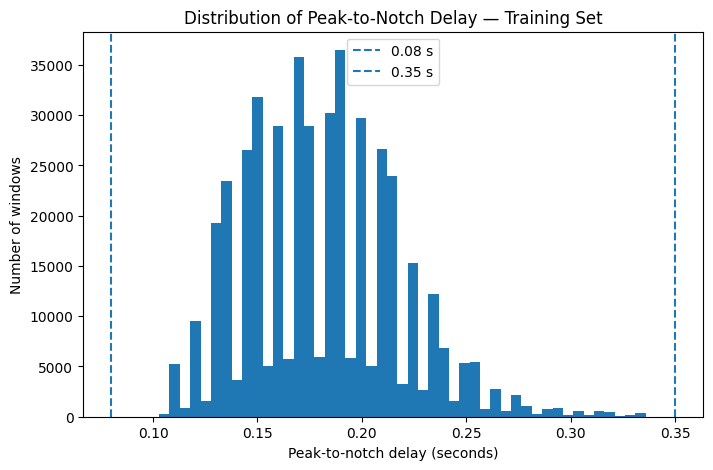

In [16]:
import matplotlib.pyplot as plt

valid_delay = delay_train[
    np.isfinite(delay_train)
]

plt.figure(figsize=(8, 5))

plt.hist(
    valid_delay,
    bins=50
)

plt.xlabel("Peak-to-notch delay (seconds)")
plt.ylabel("Number of windows")
plt.title("Distribution of Peak-to-Notch Delay — Training Set")

plt.axvline(
    0.08,
    linestyle="--",
    label="0.08 s"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="0.35 s"
)

plt.legend()

plt.show()

In [17]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("delay_train:", delay_train.shape)

print(
    "Number of windows:",
    len(X_train)
)

print(
    "Number of BP labels:",
    len(y_train)
)

print(
    "Number of delays:",
    len(delay_train)
)

X_train: torch.Size([454999, 1, 1000])
y_train: torch.Size([454999, 2])
delay_train: torch.Size([454999])
Number of windows: 454999
Number of BP labels: 454999
Number of delays: 454999


/tmp/ipykernel_1365473/3737023816.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_train[np.isfinite(delay_train), 0],
/tmp/ipykernel_1365473/3737023816.py:5: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  y_train[np.isfinite(delay_train), 0],


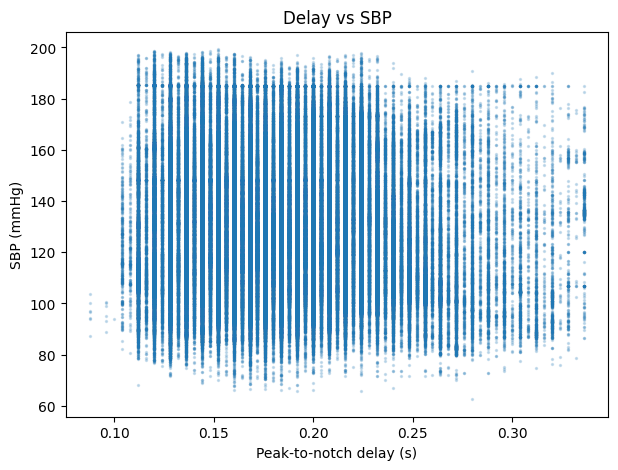

In [18]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 0],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("SBP (mmHg)")
plt.title("Delay vs SBP")

plt.show()

/tmp/ipykernel_1365473/3149313679.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_train[np.isfinite(delay_train), 1],
/tmp/ipykernel_1365473/3149313679.py:5: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  y_train[np.isfinite(delay_train), 1],


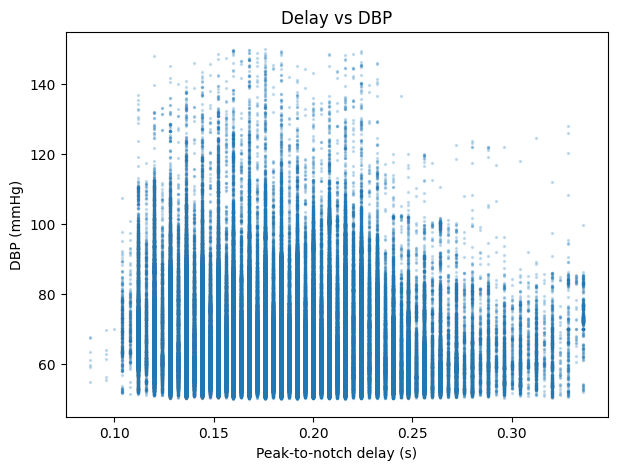

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 1],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("DBP (mmHg)")
plt.title("Delay vs DBP")

plt.show()

## RC Estimation ##

In [23]:

def estimate_RC(
    sbp,
    dbp,
    delay,
    min_delay=0.08,
    max_delay=0.35
):
    """
    Estimate Windkessel RC from training data.

    Physics:
        DBP = SBP * exp(-delay / RC)

    Therefore:
        RC = -delay / ln(DBP / SBP)

    Parameters
    ----------
    sbp : array-like
        SBP values from training windows.

    dbp : array-like
        DBP values from training windows.

    delay : array-like
        Peak-to-notch delay for training windows.

    Returns
    -------
    RC : float
        Estimated Windkessel time constant in seconds.
    """

    sbp = np.asarray(sbp, dtype=np.float64)
    dbp = np.asarray(dbp, dtype=np.float64)
    delay = np.asarray(delay, dtype=np.float64)

    # ------------------------------------------------
    # Valid values only
    # ------------------------------------------------

    valid = (
        np.isfinite(sbp) &
        np.isfinite(dbp) &
        np.isfinite(delay)
    )

    # Physiological constraints
    valid &= sbp > 0
    valid &= dbp > 0
    valid &= dbp < sbp

    # Delay constraints
    valid &= delay >= min_delay
    valid &= delay <= max_delay

    sbp_valid = sbp[valid]
    dbp_valid = dbp[valid]
    delay_valid = delay[valid]

    print("Total windows:", len(sbp))
    print("Valid windows:", len(sbp_valid))
    print(
        "Valid percentage:",
        100 * len(sbp_valid) / len(sbp),
        "%"
    )

    if len(sbp_valid) == 0:
        raise ValueError(
            "No valid samples available for RC estimation."
        )

    # ------------------------------------------------
    # Calculate RC for every valid window
    # ------------------------------------------------

    ratio = dbp_valid / sbp_valid

    RC_values = (
        -delay_valid /
        np.log(ratio)
    )

    # ------------------------------------------------
    # Remove invalid RC values
    # ------------------------------------------------

    RC_values = RC_values[
        np.isfinite(RC_values) &
        (RC_values > 0)
    ]

    if len(RC_values) == 0:
        raise ValueError(
            "No valid RC values obtained."
        )

    # ------------------------------------------------
    # Robust estimate
    # ------------------------------------------------

    RC = np.median(RC_values)

    print("\n================================")
    print("Windkessel RC Estimation")
    print("================================")

    print(
        f"Median RC : {RC:.4f} s"
    )

    print(
        f"Mean RC   : {np.mean(RC_values):.4f} s"
    )

    print(
        f"Std RC    : {np.std(RC_values):.4f} s"
    )

    print(
        f"Min RC    : {np.min(RC_values):.4f} s"
    )

    print(
        f"Max RC    : {np.max(RC_values):.4f} s"
    )

    return RC, RC_values

In [24]:
RC, RC_values = estimate_RC(
    sbp=y_train[:, 0].numpy(),
    dbp=y_train[:, 1].numpy(),
    delay=delay_train
)

Total windows: 454999
Valid windows: 454999
Valid percentage: 100.0 %

Windkessel RC Estimation
Median RC : 0.2696 s
Mean RC   : 0.2994 s
Std RC    : 0.1486 s
Min RC    : 0.1104 s
Max RC    : 4.6139 s


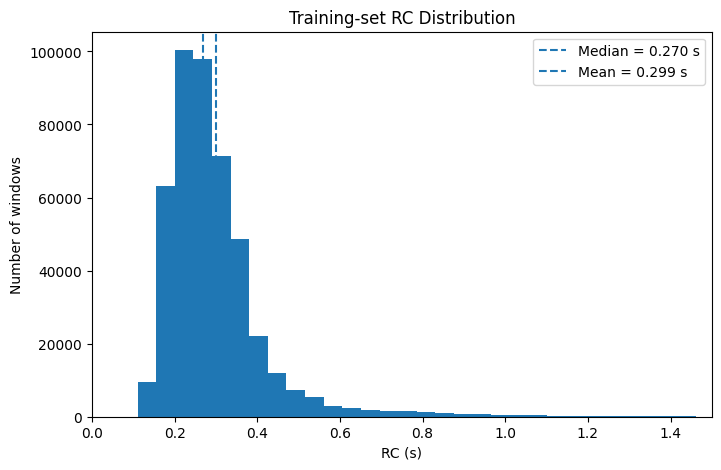

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    RC_values,
    bins=100
)

plt.axvline(
    np.median(RC_values),
    linestyle="--",
    label=f"Median = {np.median(RC_values):.3f} s"
)
plt.axvline(
    np.mean(RC_values),
    linestyle="--",
    label=f"Mean = {np.mean(RC_values):.3f} s"
)

plt.xlabel("RC (s)")
plt.xlim(0,1.5)
plt.ylabel("Number of windows")
plt.title("Training-set RC Distribution")
plt.legend()

plt.show()

It's a highly skewed distribution, so using mean won't be a good idea

In [28]:
for p in [1, 5, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(RC_values, p):.4f} s"
    )

  1.0% : 0.1465 s
  5.0% : 0.1700 s
 25.0% : 0.2200 s
 50.0% : 0.2696 s
 75.0% : 0.3348 s
 90.0% : 0.4159 s
 95.0% : 0.5160 s
 99.0% : 0.8912 s
 99.5% : 1.1039 s
 99.9% : 1.7313 s


In [33]:
RC = 0.21

sbp = y_train[:, 0].cpu().numpy()
dbp = y_train[:, 1].cpu().numpy()
delay = delay_train.cpu().numpy()

dbp_physics = (
    sbp *
    np.exp(-delay / RC)
)

physics_mae = np.mean(
    np.abs(dbp_physics - dbp)
)

physics_rmse = np.sqrt(
    np.mean(
        (dbp_physics - dbp) ** 2
    )
)

print("Physics-only DBP MAE :", physics_mae)
print("Physics-only DBP RMSE:", physics_rmse)

Physics-only DBP MAE : 14.185427
Physics-only DBP RMSE: 17.624435


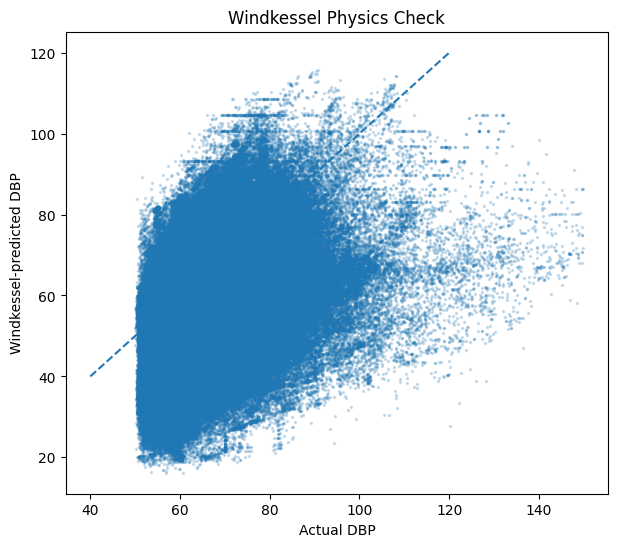

In [34]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dbp,
    dbp_physics,
    s=2,
    alpha=0.2
)

plt.plot(
    [40, 120],
    [40, 120],
    linestyle="--"
)

plt.xlabel("Actual DBP")
plt.ylabel("Windkessel-predicted DBP")
plt.title("Windkessel Physics Check")

plt.show()

In [ ]:
print("Estimated RC:", RC)
print("Median delay:", np.median(delay_train[np.isfinite(delay_train)]))
print("Median SBP:", np.median(y_train[:, 0].numpy()))
print("Median DBP:", np.median(y_train[:, 1].numpy()))

In [ ]:
print("Train delay statistics")
print("----------------------")

print("Min   :", decay_train.min().item())
print("Max   :", decay_train.max().item())
print("Mean  :", decay_train.mean().item())
print("Median:", decay_train.median().item())
print("Std   :", decay_train.std().item())

In [ ]:
print("Total windows:", len(decay_train))

num_nan = torch.isnan(decay_train).sum().item()

print("NaN windows:", num_nan)
print("Valid windows:", len(decay_train) - num_nan)
print("NaN %:", 100 * num_nan / len(decay_train))

In [ ]:
idx = 0

ppg_window = X_train[idx, 0].numpy()

sys_idx = get_systolic_peak(ppg_window)
notch_idx = get_dicrotic_notch(ppg_window, sys_idx)

print("Systolic:", sys_idx)
print("Notch:", notch_idx)
print("Delay:", get_decay_time(ppg_window))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

t = np.arange(1000) / 125

plt.figure(figsize=(12,4))
plt.plot(t, ppg_window, label="PPG")

if sys_idx is not None:
    plt.scatter(
        t[sys_idx],
        ppg_window[sys_idx],
        c="red",
        s=80,
        label="Systolic"
    )

if notch_idx is not None:
    plt.scatter(
        t[notch_idx],
        ppg_window[notch_idx],
        c="green",
        s=80,
        label="Notch"
    )

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_landmarks(
    X,
    indices,
    fs=125
):

    for idx in indices:

        ppg = X[idx, 0].numpy()

        sys_idx = get_systolic_peak(
            ppg,
            fs
        )

        notch_idx = get_dicrotic_notch(
            ppg,
            sys_idx,
            fs
        )

        time = np.arange(
            len(ppg)
        ) / fs


        plt.figure(figsize=(12, 4))

        plt.plot(
            time,
            ppg,
            label="PPG"
        )


        if sys_idx is not None:

            plt.scatter(
                time[sys_idx],
                ppg[sys_idx],
                s=70,
                label="Systolic peak"
            )


        if notch_idx is not None:

            plt.scatter(
                time[notch_idx],
                ppg[notch_idx],
                s=70,
                label="Dicrotic notch"
            )


        plt.xlabel("Time (s)")
        plt.ylabel("Normalized PPG")

        plt.title(
            f"Window {idx}"
        )

        plt.legend()
        plt.grid()

        plt.show()

In [ ]:
plot_landmarks(
    X_train,
    [0, 100, 500, 1000, 5000]
)